# Setup

In [13]:
!pip install mujoco gymnasium matplotlib imageio numpy torch torchvision timm transformers open_clip_torch tqdm


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os
import sys
import json
import torch
import random
import numpy as np

os.chdir("/content/drive/MyDrive/visual-policy-learning")

os.environ["MUJOCO_GL"] = "egl"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
import importlib

import envs.panda_reach_env
importlib.reload(envs.panda_reach_env)

from envs.panda_reach_env import PandaReachEnv

In [17]:
import evals.eval_utils
importlib.reload(evals.eval_utils)
from evals.eval_utils import evaluate_policy, rollout_episode

In [18]:
import policies.encoders.resnet_encoder
import policies.encoders.clip_encoder
import policies.encoders.dinov2_encoder
import policies.base_policy
import policies.action_head
import policies.load_policy

importlib.reload(policies.encoders.resnet_encoder)
importlib.reload(policies.encoders.clip_encoder)
importlib.reload(policies.encoders.dinov2_encoder)
importlib.reload(policies.base_policy)
importlib.reload(policies.action_head)
importlib.reload(policies.load_policy)

from policies.encoders.resnet_encoder import ResNetEncoder
from policies.encoders.clip_encoder import CLIPEncoder
from policies.encoders.dinov2_encoder import DINOv2Encoder

from policies.base_policy import BasePolicy
from policies.action_head import ActionHead
from policies.load_policy import load_policy


In [19]:
def make_env():
    return PandaReachEnv(
        render_mode=True,
        image_width=64,
        image_height=64,
        verbose=False,
        physics_steps=4,
    )


# Testing

In [20]:
import h5py
import numpy as np

with h5py.File("data/panda_demos_rendered.h5", "r") as f:

    actions = f["actions"][:]

print("Action shape:", actions.shape)

print("\nAction min:")
print(actions.min(axis=0))

print("\nAction max:")
print(actions.max(axis=0))

print("\nAction mean:")
print(actions.mean(axis=0))

print("\nAction std:")
print(actions.std(axis=0))

Action shape: (1541, 8)

Action min:
[-0.69858617  0.05877033 -0.8086155  -2.1574142  -0.5        -0.0175
 -0.07453137  0.        ]

Action max:
[ 0.6920169   1.2170383   0.7710434  -0.0698      0.5         0.74483114
  0.          0.        ]

Action mean:
[ 0.00506162  0.59635806  0.00644349 -1.0280404   0.01290389 -0.00289662
 -0.06514584  0.        ]

Action std:
[0.21990307 0.1981907  0.25333846 0.57406944 0.15994073 0.06985827
 0.01687349 0.        ]


In [21]:
env = make_env()
obs, _ = env.reset()

print("mean:", obs["image"].mean())
print("std:", obs["image"].std())
print("min/max:", obs["image"].min(), obs["image"].max())

mean: 97.2470703125
std: 43.023731768910764
min/max: 13 255


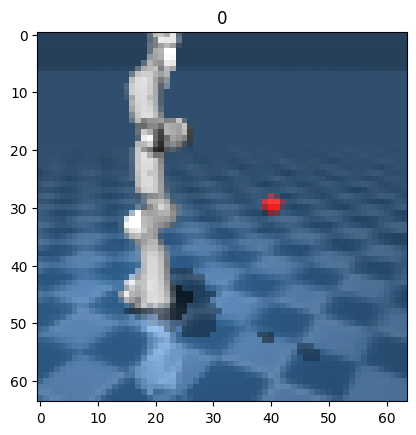

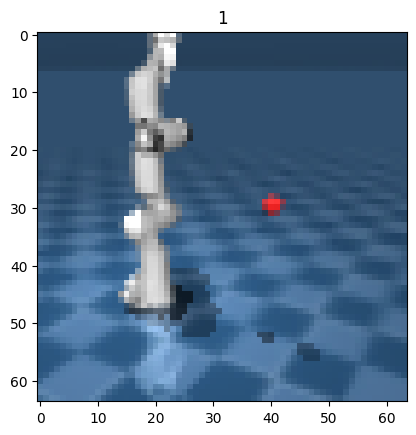

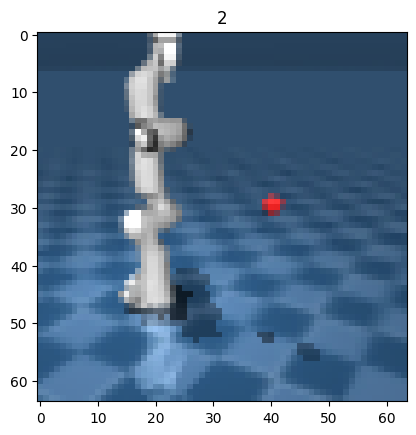

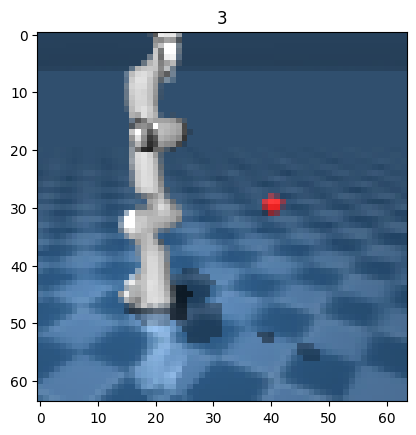

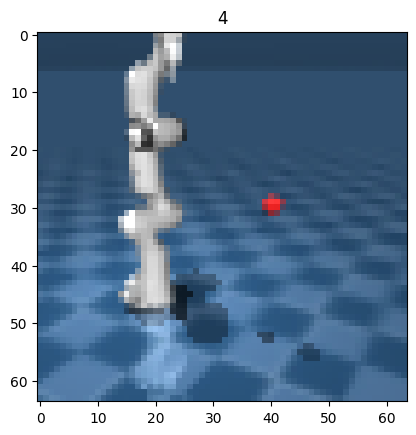

In [22]:
import matplotlib.pyplot as plt

env = make_env()
obs, _ = env.reset()

for i in range(5):
    obs, _, _, _, _ = env.step(env.action_space.sample())
    plt.imshow(obs["image"])
    plt.title(i)
    plt.show()

# Evalutation

In [23]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


resnet_model = load_policy(
    ResNetEncoder(),
    encoder_dim=512,
    action_dim=8,
    path="models/resnet_frozen.pt",
    device=DEVICE
)

dino_model = load_policy(
    DINOv2Encoder(),
    encoder_dim=384,
    action_dim=8,
    path="models/dino_frozen.pt",
    device=DEVICE
)

clip_model = load_policy(
    CLIPEncoder(),
    encoder_dim=512,
    action_dim=8,
    path="models/clip_frozen.pt",
    device=DEVICE
)

models = {
    "dino": dino_model,
    "resnet": resnet_model,
    "clip": clip_model,
}

for m in models.values():
    m.to(DEVICE)


Loaded: models/resnet_frozen.pt
(encoder weights come from pretrained backbone, not checkpoint)

Loaded: models/dino_frozen.pt
(encoder weights come from pretrained backbone, not checkpoint)

Loaded: models/clip_frozen.pt
(encoder weights come from pretrained backbone, not checkpoint)


In [24]:
eval_results = {}

for model_name, model in models.items():

    print(f"\nEvaluating {model_name}")

    metrics = evaluate_policy(
        env_fn=make_env,
        policy=model,
        num_episodes=5,
        max_steps=300,
    )

    eval_results[model_name] = metrics

    print(metrics)



Evaluating resnet


100%|██████████| 5/5 [03:58<00:00, 47.64s/it]


{'success_rate': 0.8, 'avg_reward': -14.722587195362559, 'avg_steps': 56.2, 'reward_std': 9.523183158443718}

Evaluating dino


100%|██████████| 5/5 [05:47<00:00, 69.54s/it]


{'success_rate': 0.6, 'avg_reward': -20.119211755276933, 'avg_steps': 69.8, 'reward_std': 11.026841027122975}

Evaluating clip


100%|██████████| 5/5 [03:25<00:00, 41.09s/it]

{'success_rate': 1.0, 'avg_reward': -10.590704487208846, 'avg_steps': 43.0, 'reward_std': 2.8699775922077593}


In [25]:
os.makedirs(
    "results/metrics",
    exist_ok=True
)

with open(
    "results/metrics/eval_results.json",
    "w"
) as f:

    json.dump(eval_results, f, indent=4)

# Robustness

In [26]:
import importlib
import evals.eval_utils
import evals.robustness_tests

importlib.reload(evals.eval_utils)
importlib.reload(evals.robustness_tests)

from evals.robustness_tests import run_robustness_suite
from evals.eval_utils import evaluate_policy, rollout_episode

In [27]:
robustness_results = run_robustness_suite(
    env_fn=make_env,
    models=models,
    num_episodes=1,
)


=== normal ===


100%|██████████| 1/1 [00:54<00:00, 54.57s/it]


resnet {'success_rate': 1.0, 'avg_reward': -16.446945822604025, 'avg_steps': 71.0, 'reward_std': 0.0}


100%|██████████| 1/1 [00:36<00:00, 36.57s/it]


dino {'success_rate': 1.0, 'avg_reward': -9.244059660944309, 'avg_steps': 37.0, 'reward_std': 0.0}


...

resnet {'success_rate': 0.0, 'avg_reward': -34.28973986954226, 'avg_steps': 100.0, 'reward_std': 0.0}


100%|██████████| 1/1 [01:38<00:00, 98.36s/it]


dino {'success_rate': 0.0, 'avg_reward': -42.73043158523317, 'avg_steps': 100.0, 'reward_std': 0.0}


100%|██████████| 1/1 [01:34<00:00, 94.25s/it]

clip {'success_rate': 0.0, 'avg_reward': -33.480560908285064, 'avg_steps': 100.0, 'reward_std': 0.0}


In [28]:
with open(
    "results/metrics/robustness_results.json",
    "w"
) as f:

    json.dump(robustness_results, f, indent=4)

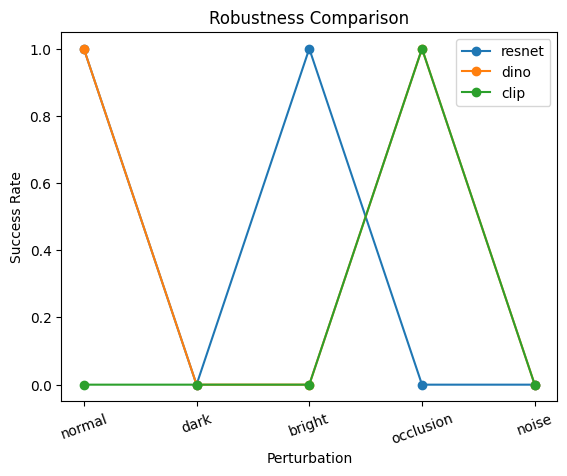

In [29]:
import matplotlib.pyplot as plt

tests = list(robustness_results.keys())

for model_name in models.keys():

    vals = []

    for test in tests:

        vals.append(
            robustness_results[test][model_name]["success_rate"]
        )

    plt.plot(
        tests,
        vals,
        marker='o',
        label=model_name
    )

plt.ylabel("Success Rate")
plt.xlabel("Perturbation")
plt.title("Robustness Comparison")
plt.legend()

plt.xticks(rotation=20)

plt.show()

# Videos

In [30]:
def make_video_env():
    return PandaReachEnv(
        render_mode=True,
        image_width=64,
        image_height=64,
        verbose=False,
        physics_steps=4
    )

In [31]:
import os
os.makedirs("videos", exist_ok=True)

for model_name, model in models.items():

    print("Saving video for:", model_name)

    video_env = make_video_env()

    rollout_episode(
        video_env,
        model,
        max_steps=300,
        save_video=True,
        video_path=f"videos/{model_name}_demo.mp4",
        render_every=2,
    )

    video_env.close()


Saving video for: resnet
Saving video for: dino
Saving video for: clip
